<a href="https://colab.research.google.com/github/hamzali369/Regression-anaylsis/blob/main/Polynomial_regression_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FIRST 5 ROWS OF DATASET:

          X           Y
0 -2.509198  -91.754635
1  9.014286  211.121757
2  4.639879   51.372749
3  1.973170  -51.746257
4 -6.879627 -186.925312

Training Size: 8000
Testing Size : 2000

MODEL PERFORMANCE
Mean Squared Error : 2419.4400832246274
R² Score           : 0.9443731716627716

POLYNOMIAL EQUATION
Intercept: 5.679297139933844
Coefficient for x^1: 1.837622664736438
Coefficient for x^2: -1.495892600615416
Coefficient for x^3: 0.5015701486909372


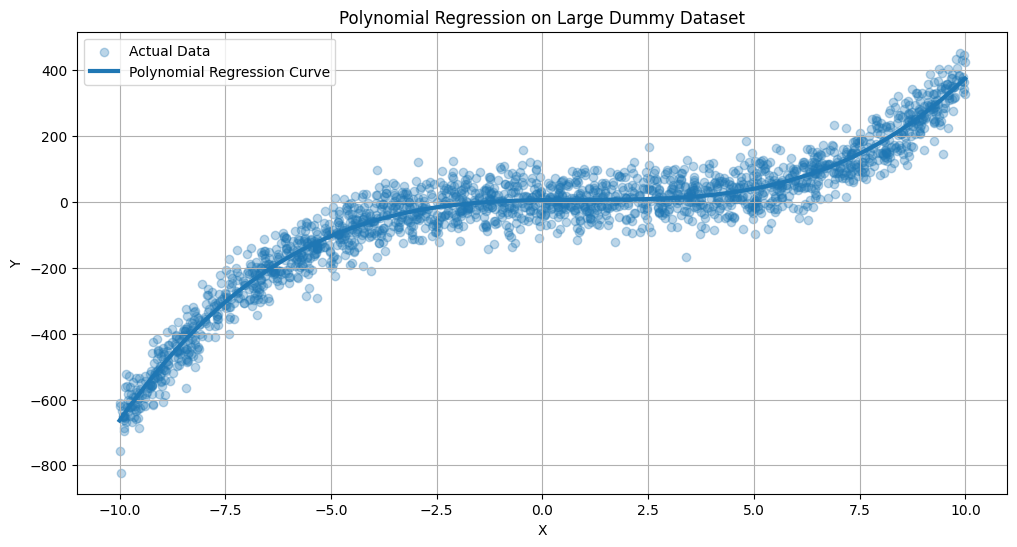



FUTURE PREDICTIONS
X = -7 --> Predicted Y = -252.52135994436804
X = -2 --> Predicted Y = -7.992079781528194
X = 0 --> Predicted Y = 5.679297139933844
X = 3 --> Predicted Y = 11.271525743259716
X = 8 --> Predicted Y = 181.44706814819855

INTERPRETATION

1. Polynomial Regression is used when the relationship
   between variables is non-linear.

2. Instead of fitting a straight line, the model fits
   a curved relationship.

3. Degree = 3 means:
   - x
   - x²
   - x³
   are included in the model.

4. Higher R² score indicates better model fitting.

5. The graph shows how polynomial regression captures
   curved patterns better than simple linear regression.



In [2]:
# POLYNOMIAL REGRESSION MODEL
# COMPLETE IMPLEMENTATION WITH LARGE DUMMY DATASET

# ============================================================
# IMPORT LIBRARIES


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# sklearn modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# STEP 1: GENERATE LARGE DUMMY DATASET


# Setting random seed for reproducibility
np.random.seed(42)

# Number of observations
n = 10000

# Generate independent variable X
# Random values between -10 and 10
X = np.random.uniform(-10, 10, n)

# CREATE NON-LINEAR RELATIONSHIP
# ============================================================

# True polynomial relationship:
#
# y = 5 + 2x - 1.5x² + 0.5x³ + noise
#
# Adding noise makes data realistic

noise = np.random.normal(0, 50, n)

y = 5 + (2 * X) - (1.5 * X**2) + (0.5 * X**3) + noise

# CONVERT INTO DATAFRAME
# ============================================================

data = pd.DataFrame({
    'X': X,
    'Y': y
})

print("FIRST 5 ROWS OF DATASET:\n")
print(data.head())

# STEP 2: PREPARE DATA
# ============================================================

# Independent variable must be 2D
X = X.reshape(-1, 1)

# Dependent variable
Y = y

# STEP 3: SPLIT DATA INTO TRAINING & TESTING
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Size:", len(X_train))
print("Testing Size :", len(X_test))

# ============================================================
# STEP 4: TRANSFORM DATA INTO POLYNOMIAL FEATURES

# Polynomial degree
degree = 3

# Create polynomial features
poly = PolynomialFeatures(degree=degree)

# Transform training and testing data
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# ============================================================
# STEP 5: TRAIN POLYNOMIAL REGRESSION MODEL

model = LinearRegression()

# Fit model
model.fit(X_train_poly, y_train)

# ============================================================
# STEP 6: MAKE PREDICTIONS

y_pred = model.predict(X_test_poly)

# ============================================================
# STEP 7: EVALUATE MODEL

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# R² Score
r2 = r2_score(y_test, y_pred)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print("Mean Squared Error :", mse)
print("R² Score           :", r2)

# ============================================================
# STEP 8: DISPLAY MODEL EQUATION

print("\n==============================")
print("POLYNOMIAL EQUATION")
print("==============================")

# Coefficients
coefficients = model.coef_

# Intercept
intercept = model.intercept_

print(f"Intercept: {intercept}")

for i in range(1, len(coefficients)):
    print(f"Coefficient for x^{i}: {coefficients[i]}")

# ============================================================
# STEP 9: VISUALIZATION

# Sorting values for smooth curve plotting
sorted_indices = np.argsort(X_test.flatten())

X_sorted = X_test.flatten()[sorted_indices]
y_sorted = y_pred[sorted_indices]

# Create figure
plt.figure(figsize=(12,6))

# Scatter plot of actual data
plt.scatter(
    X_test,
    y_test,
    alpha=0.3,
    label='Actual Data'
)

# Polynomial regression curve
plt.plot(
    X_sorted,
    y_sorted,
    linewidth=3,
    label='Polynomial Regression Curve'
)

# Labels
plt.title("Polynomial Regression on Large Dummy Dataset")
plt.xlabel("X")
plt.ylabel("Y")

plt.legend()
plt.grid()

plt.show()

# ============================================================
# STEP 10: FUTURE PREDICTIONS

# New unseen values
future_X = np.array([[-7], [-2], [0], [3], [8]])

# Transform into polynomial features
future_X_poly = poly.transform(future_X)

# Predict
future_predictions = model.predict(future_X_poly)

print("\n")
print("FUTURE PREDICTIONS")
print("==============================")

for i in range(len(future_X)):
    print(f"X = {future_X[i][0]} --> Predicted Y = {future_predictions[i]}")

# ============================================================
# FINAL INTERPRETATION

print("\n==============================")
print("INTERPRETATION")
print("==============================")

print("""
1. Polynomial Regression is used when the relationship
   between variables is non-linear.

2. Instead of fitting a straight line, the model fits
   a curved relationship.

3. Degree = 3 means:
   - x
   - x²
   - x³
   are included in the model.

4. Higher R² score indicates better model fitting.

5. The graph shows how polynomial regression captures
   curved patterns better than simple linear regression.
""")